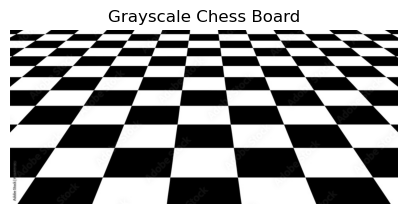

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read the image
chess_img_color = cv2.imread('Assignment3_Files/Chess_Board.jpg')
# Convert to grayscale
chess_img_gray = cv2.cvtColor(chess_img_color, cv2.COLOR_BGR2GRAY)

# Display the grayscale image
plt.figure(figsize=(5,5))
plt.title("Grayscale Chess Board")
plt.imshow(chess_img_gray, cmap='gray')
plt.axis('off')
plt.show()


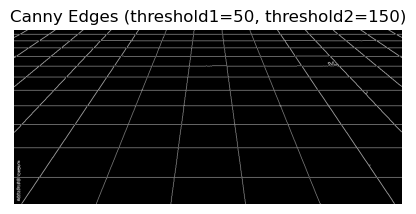

In [2]:
# Apply Canny Edge Detector
threshold1 = 50
threshold2 = 150

chess_edges = cv2.Canny(chess_img_gray, threshold1, threshold2)

# Display the edges
plt.figure(figsize=(5,5))
plt.title(f"Canny Edges (threshold1={threshold1}, threshold2={threshold2})")
plt.imshow(chess_edges, cmap='gray')
plt.axis('off')
plt.show()


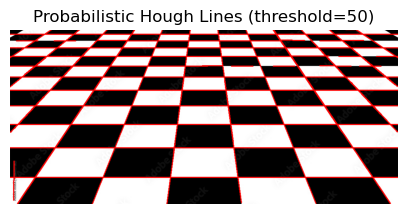

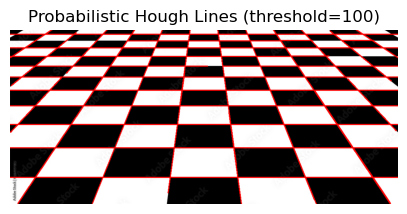

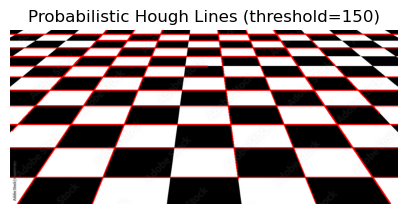

In [3]:
# Probabilistic Hough Transform
# threshold ~ minimum number of votes
min_line_length = 50
max_line_gap = 10
threshold_values = [50, 100, 150]

for thr in threshold_values:
    linesP = cv2.HoughLinesP(chess_edges, rho=1, theta=np.pi/180, threshold=thr,
                             minLineLength=min_line_length, maxLineGap=max_line_gap)
    
    chess_with_linesP = chess_img_color.copy()
    if linesP is not None:
        for line in linesP:
            x1, y1, x2, y2 = line[0]
            cv2.line(chess_with_linesP, (x1, y1), (x2, y2), (0, 0, 255), 2)
    
    plt.figure(figsize=(5,5))
    plt.title(f"Probabilistic Hough Lines (threshold={thr})")
    plt.imshow(cv2.cvtColor(chess_with_linesP, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()


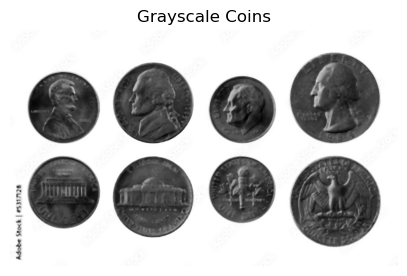

In [9]:
coins_img_color = cv2.imread('Assignment3_Files/Coins.jpg')
coins_img_gray = cv2.cvtColor(coins_img_color, cv2.COLOR_BGR2GRAY)

# Blur slightly to reduce noise.
coins_img_blur = cv2.medianBlur(coins_img_gray, 5)

plt.figure(figsize=(5,5))
plt.title("Grayscale Coins")
plt.imshow(coins_img_blur, cmap='gray')
plt.axis('off')
plt.show()


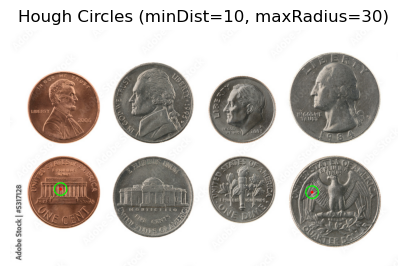

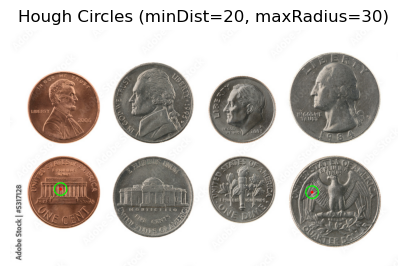

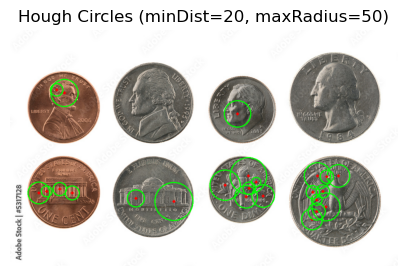

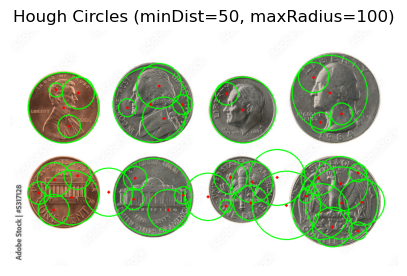

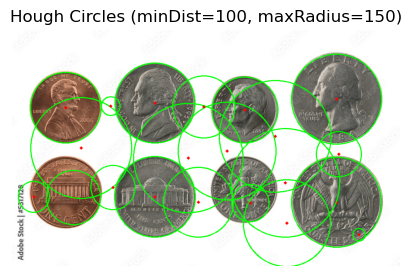

In [13]:
param1 = 100     # used for Canny's high threshold (low threshold is param1/2 if we don't specify)
param2 = 30      # threshold for center detection in Hough space
dp = 1           # inverse ratio of the accumulator resolution
min_radius = 0

# Experiment with minDist and maxRadius
pairs_of_params = [
    (10, 30),  # (minDist=10, maxRadius=30)
    (20, 30),  
    (20, 50),
    (50, 100),
    (100, 150)
]

for minDist, maxRadius in pairs_of_params:
    # HoughCircles returns circles in (x_center, y_center, radius)
    circles = cv2.HoughCircles(
        coins_img_blur, cv2.HOUGH_GRADIENT, dp,
        minDist=minDist,
        param1=param1, param2=param2,
        minRadius=min_radius, maxRadius=maxRadius
    )
    
    # Draw the circles
    coins_with_circles = coins_img_color.copy()
    if circles is not None:
        circles = np.uint16(np.around(circles))
        for c in circles[0, :]:
            # center
            center = (c[0], c[1])
            # radius
            radius = c[2]
            # circle center
            cv2.circle(coins_with_circles, center, 2, (0, 0, 255), 3)
            # circle outline
            cv2.circle(coins_with_circles, center, radius, (0, 255, 0), 2)
    
    plt.figure(figsize=(5,5))
    plt.title(f"Hough Circles (minDist={minDist}, maxRadius={maxRadius})")
    plt.imshow(cv2.cvtColor(coins_with_circles, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()
